# NutriSync — Notebook 2: USDA FoodData Central Dataset
## Data Cleaning, Bug Investigation, EDA & Pipeline Preparation

**Dataset:** USDA FoodData Central — Foundation Foods + SR Legacy  
**Source:** https://fdc.nal.usda.gov/download-foods  
**Raw inputs:** Multi-file relational CSV format (ZIP archives)  
**Final rows:** 5,005 food items after processing  
**Columns:** 19 — fdc_id, food_name, category, calories, protein_g, fat_g, carbs_g, fiber_g, sugar_g, sodium_mg, iron_mg, magnesium_mg, calcium_mg, potassium_mg, vitamin_c_mg, vitamin_d_mcg, omega3_g  

**Purpose in Pipeline:**  
Used by Module 5 (USDA Database) to look up verified nutrition values for any ingredient the user provides.  
This prevents the LLM from hallucinating calorie counts.

**What this notebook covers:**
1. Why raw USDA data requires complex processing (multi-file structure)
2. The calorie bug — root cause analysis and fix
3. Loading and inspecting the processed dataset
4. Data quality checks
5. Full EDA — distributions, correlations, category analysis
6. Pipeline feasibility validation — cuisine coverage
7. Focus nutrient analysis — mapping biometric flags to food sources

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0D1B2A',
    'axes.facecolor':   '#0D1B2A',
    'axes.edgecolor':   '#64748B',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

TEAL  = '#0D9488'
MINT  = '#14B8A6'
ORNG  = '#F97316'
WHITE = '#FFFFFF'
GRAY  = '#64748B'
DARK  = '#0D1B2A'

NUTRITION_COLS = [
    'calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g',
    'sodium_mg', 'iron_mg', 'magnesium_mg', 'calcium_mg',
    'potassium_mg', 'vitamin_c_mg', 'vitamin_d_mcg', 'omega3_g'
]
print("Libraries loaded.")

Libraries loaded.


---
## Section 1 — Why the USDA Data Requires Complex Processing

The USDA download is **not a single flat CSV**. It is a ZIP file containing a relational database spread across multiple files:

```
food.csv              → food names + fdc_id (one row per food)
food_nutrient.csv     → LONG FORMAT: one row per food-nutrient pair
                        (a single chicken breast = 80+ rows here)
nutrient.csv          → maps nutrient_id → "Protein", "Iron, Fe", etc.
food_category.csv     → maps category_id → "Poultry Products"
```

To answer "how much protein does chicken breast have?" you must JOIN all four files.  
Our `usda_processor.py` does this automatically.

In [4]:
# Demonstrate the LONG format structure that food_nutrient.csv uses
# This is what the raw data looks like BEFORE our processor runs

print("food.csv structure (food names):")
print("  fdc_id | description              | data_type    | food_category_id")
print("  319877 | Hummus                   | foundation.. | 16")
print("  167512 | Pillsbury Biscuits       | sr_legacy..  | 18")
print()
print("food_nutrient.csv structure (LONG format — the challenge):")
print("  fdc_id | nutrient_id | amount")
print("  319877 | 1003        | 7.35    ← protein")
print("  319877 | 1004        | 17.10   ← fat")
print("  319877 | 1008        | 243.0   ← calories (SR Legacy)")
print("  319877 | 2047        | 243.0   ← calories (Foundation Foods)")
print("  319877 | 1087        | 41.0    ← calcium")
print("  319877 | ...         | ...     ← 80+ more rows for this one food")
print()
print("nutrient.csv (the ID→name mapping):")
print("  id   | name")
print("  1003 | Protein")
print("  1004 | Total lipid (fat)")
print("  1008 | Energy                          ← SR Legacy uses this")
print("  2047 | Energy (Atwater General Factors) ← Foundation uses this")
print()
print("Our processor joins all 4 files and pivots from LONG → WIDE format.")
print("Result: one row per food with columns for each nutrient.")

food.csv structure (food names):
  fdc_id | description              | data_type    | food_category_id
  319877 | Hummus                   | foundation.. | 16
  167512 | Pillsbury Biscuits       | sr_legacy..  | 18

food_nutrient.csv structure (LONG format — the challenge):
  fdc_id | nutrient_id | amount
  319877 | 1003        | 7.35    ← protein
  319877 | 1004        | 17.10   ← fat
  319877 | 1008        | 243.0   ← calories (SR Legacy)
  319877 | 2047        | 243.0   ← calories (Foundation Foods)
  319877 | 1087        | 41.0    ← calcium
  319877 | ...         | ...     ← 80+ more rows for this one food

nutrient.csv (the ID→name mapping):
  id   | name
  1003 | Protein
  1004 | Total lipid (fat)
  1008 | Energy                          ← SR Legacy uses this
  2047 | Energy (Atwater General Factors) ← Foundation uses this

Our processor joins all 4 files and pivots from LONG → WIDE format.
Result: one row per food with columns for each nutrient.


---
## Section 2 — Root Cause Analysis: The Calorie Bug

This was the most important data quality issue we discovered.  
It caused **249 food items to show 0 calories** in our first processed output.

In [5]:
# ── The problem ────────────────────────────────────────────────────────────
print("THE BUG:")
print("=" * 55)
print()
print("Our first processor extracted calories using:")
print("   nutrient_id = 1008  ('Energy')")
print()
print("But Foundation Foods does NOT store calories under 1008.")
print("It stores them under:")
print("   nutrient_id = 2047  ('Energy, Atwater General Factors')")
print()
print("SR Legacy uses 1008.")
print("Foundation Foods uses 2047.")
print("These are different IDs for the same concept.")
print()
print("Example — Sea Bass (fdc_id 2747668, Foundation Foods):")
print("  nutrient_id 1008 → NOT PRESENT  (returns 0)")
print("  nutrient_id 2047 → 209.4 kcal   (the real value)")
print()
print("THE FIX:")
print("=" * 55)
print("Extract BOTH nutrient_ids. For each food item, pick the")
print("best available value in priority order:")
print("  1st: nutrient_id 2047  (Foundation preferred)")
print("  2nd: nutrient_id 1008  (SR Legacy preferred)")
print("  3rd: nutrient_id 2048  (Atwater Specific, fallback)")

THE BUG:

Our first processor extracted calories using:
   nutrient_id = 1008  ('Energy')

But Foundation Foods does NOT store calories under 1008.
It stores them under:
   nutrient_id = 2047  ('Energy, Atwater General Factors')

SR Legacy uses 1008.
Foundation Foods uses 2047.
These are different IDs for the same concept.

Example — Sea Bass (fdc_id 2747668, Foundation Foods):
  nutrient_id 1008 → NOT PRESENT  (returns 0)
  nutrient_id 2047 → 209.4 kcal   (the real value)

THE FIX:
Extract BOTH nutrient_ids. For each food item, pick the
best available value in priority order:
  1st: nutrient_id 2047  (Foundation preferred)
  2nd: nutrient_id 1008  (SR Legacy preferred)
  3rd: nutrient_id 2048  (Atwater Specific, fallback)


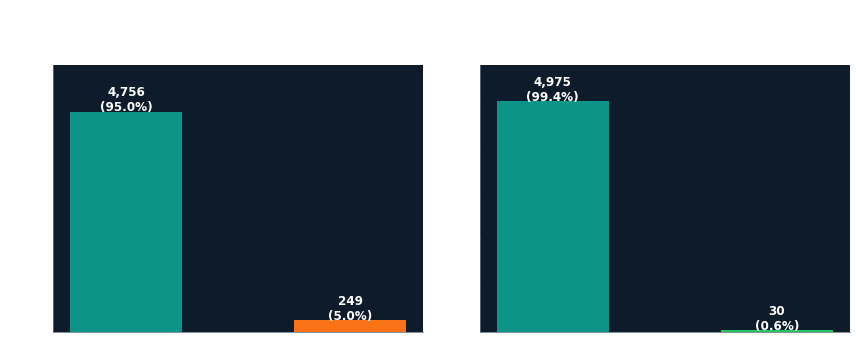

Improvement: 219 items recovered
Coverage before fix: 95.0%
Coverage after fix : 99.4%


In [6]:
# Visualise the before/after impact of the calorie bug fix
total = 5005
before_zero = 249
after_zero  = 30

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Calorie Bug: Before vs After Fix', fontweight='bold', fontsize=13)

for i, (title, zero) in enumerate([
    ('BEFORE Fix\n(nutrient_id=1008 only)', before_zero),
    ('AFTER Fix\n(1008 + 2047 merged)',     after_zero),
]):
    ax = axes[i]
    nonzero = total - zero
    bars = ax.bar(['Has Calories', 'Zero Calories'],
                  [nonzero, zero],
                  color=[TEAL, ORNG if zero > 50 else '#22C55E'],
                  width=0.5)
    for bar, val in zip(bars, [nonzero, zero]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f'{val:,}\n({val/total*100:.1f}%)',
                ha='center', fontsize=12, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Number of Food Items')
    ax.set_ylim(0, total * 1.15)

plt.tight_layout()
plt.show()
print(f"Improvement: {before_zero - after_zero} items recovered")
print(f"Coverage before fix: {(total-before_zero)/total*100:.1f}%")
print(f"Coverage after fix : {(total-after_zero)/total*100:.1f}%")

---
## Section 3 — Load Processed Dataset

We load the output of `usda_processor.py` — one clean flat CSV with one row per food item.

In [14]:
# Load the processed USDA dataset
# This file was generated by: python data/usda_processor.py
data = "C:\\Users\\Srikar\\OneDrive\\Documents\\Capstone Project Final Semester\\nutrisync\\data\\processed\\usda_nutrition_processed.csv"
df = pd.read_csv(data)

print(f"Shape      : {df.shape}")
print(f"Columns    : {df.columns.tolist()}")
print(f"Data types :")
print(df.dtypes.to_string())

Shape      : (5005, 19)
Columns    : ['fdc_id', 'food_name', 'food_name_lower', 'data_source', 'category', 'calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'iron_mg', 'magnesium_mg', 'calcium_mg', 'potassium_mg', 'vitamin_c_mg', 'vitamin_d_mcg', 'omega3_g']
Data types :
fdc_id               int64
food_name           object
food_name_lower     object
data_source         object
category            object
calories           float64
protein_g          float64
fat_g              float64
carbs_g            float64
fiber_g            float64
sugar_g            float64
sodium_mg          float64
iron_mg            float64
magnesium_mg       float64
calcium_mg         float64
potassium_mg       float64
vitamin_c_mg       float64
vitamin_d_mcg      float64
omega3_g           float64


In [15]:
print("First 8 rows:")
df[['food_name', 'data_source', 'category', 'calories',
    'protein_g', 'fat_g', 'carbs_g']].head(8)

First 8 rows:


,food_name,data_source,category,calories,protein_g,fat_g,carbs_g
0,"Watermelon, seedless, rind only, raw",Foundation,Fruits and Fruit Juices,23.9,0.53,0.97,3.27
1,"Broccoli, raw",Foundation,Vegetables and Vegetable Products,32.0,2.57,0.34,6.29
2,"Milk, lowfat, fluid, 1% milkfat, with added vi...",Foundation,Dairy and Egg Products,43.0,3.38,0.95,5.19
3,"Milk, nonfat, fluid, with added vitamin A and ...",Foundation,Dairy and Egg Products,34.0,3.43,0.08,4.89
4,"Milk, whole, 3.25% milkfat, with added vitamin D",Foundation,Dairy and Egg Products,60.0,3.28,3.20,4.67
5,"Nuts, almonds, dry roasted, with salt added",Foundation,Nut and Seed Products,667.0,20.40,57.80,16.20
6,"Cheese, ricotta, whole milk",Foundation,Dairy and Egg Products,157.0,7.81,11.00,6.86
7,"Kale, raw",Foundation,Vegetables and Vegetable Products,43.0,2.92,1.49,4.42


---
## Section 4 — Data Quality Assessment

In [16]:
print("DATA QUALITY REPORT")
print("=" * 55)

# 4.1 Source breakdown
print("\n── Data Source Breakdown ────────────────────────────")
print(df['data_source'].value_counts().to_string())

# 4.2 Category breakdown
print("\n── Category Breakdown ───────────────────────────────")
print(df['category'].value_counts().to_string())

# 4.3 Null and zero values
print("\n── Null and Zero Coverage by Nutrition Column ───────")
quality = pd.DataFrame({
    'Null Count' : df[NUTRITION_COLS].isnull().sum(),
    'Zero Count' : (df[NUTRITION_COLS] == 0).sum(),
    'Zero %'     : ((df[NUTRITION_COLS] == 0).sum() / len(df) * 100).round(1),
    'Coverage %' : ((df[NUTRITION_COLS] > 0).sum() / len(df) * 100).round(1),
})
print(quality.to_string())
print()
print("Note: High zero % on fiber_g, sugar_g, vitamin_c_mg, omega3_g is expected.")
print("Many meat and grain products genuinely have zero or trace values.")

DATA QUALITY REPORT

── Data Source Breakdown ────────────────────────────
data_source
SR_Legacy     4667
Foundation     338

── Category Breakdown ───────────────────────────────
category
Beef Products                        961
Vegetables and Vegetable Products    876
Lamb, Veal, and Game Products        465
Fruits and Fruit Juices              393
Poultry Products                     392
Pork Products                        343
Legumes and Legume Products          327
Dairy and Egg Products               313
Finfish and Shellfish Products       286
Cereal Grains and Pasta              222
Fats and Oils                        215
Nut and Seed Products                151
Spices and Herbs                      61

── Null and Zero Coverage by Nutrition Column ───────
               Null Count  Zero Count  Zero %  Coverage %
calories                0          30     0.6        99.4
protein_g               0         117     2.3        97.7
fat_g                   0          36     0.7    

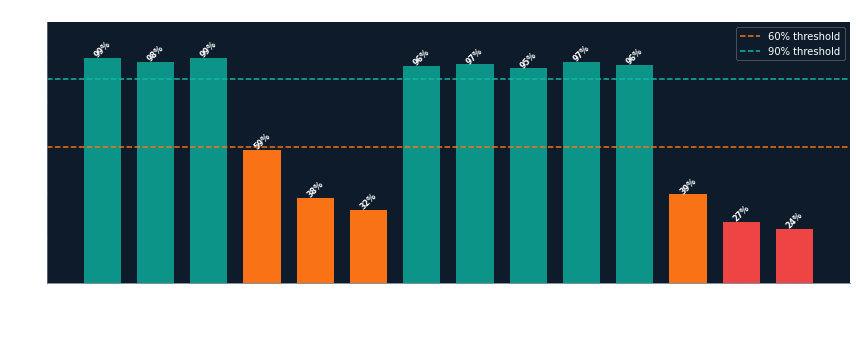

In [17]:
# Visualise coverage
fig, ax = plt.subplots(figsize=(12, 5))
coverage = (df[NUTRITION_COLS] > 0).sum() / len(df) * 100
colors = [TEAL if v >= 60 else (ORNG if v >= 30 else '#EF4444') for v in coverage.values]
bars = ax.bar(coverage.index, coverage.values, color=colors, width=0.7)
ax.axhline(60, color=ORNG, linestyle='--', lw=1.5, label='60% threshold')
ax.axhline(90, color=MINT,  linestyle='--', lw=1.5, label='90% threshold')
for bar, val in zip(bars, coverage.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold', rotation=45)
ax.set_ylabel('Coverage (%)')
ax.set_title('Nutrition Column Coverage — % of Items with Non-Zero Values', fontweight='bold')
ax.set_xticklabels(coverage.index, rotation=35, ha='right')
ax.set_ylim(0, 115)
ax.legend(framealpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 5 — Exploratory Data Analysis (EDA)

In [18]:
# Descriptive statistics — macronutrients
print("Descriptive Statistics — Core Nutrition Columns:")
df[['calories','protein_g','fat_g','carbs_g','fiber_g','sodium_mg']].describe().round(2)

Descriptive Statistics — Core Nutrition Columns:


,calories,protein_g,fat_g,carbs_g,fiber_g,sodium_mg
count,5005.00,5005.00,5005.00,5005.00,5005.00,5005.00
mean,200.41,14.67,11.39,10.41,1.70,176.54
std,171.00,11.38,18.82,18.48,4.49,429.85
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,88.00,2.57,0.64,0.00,0.00,18.00
50%,159.00,16.92,4.86,1.40,0.00,62.00
75%,253.00,23.69,12.79,13.05,1.72,108.00
max,902.00,88.32,100.00,93.53,79.00,9690.00


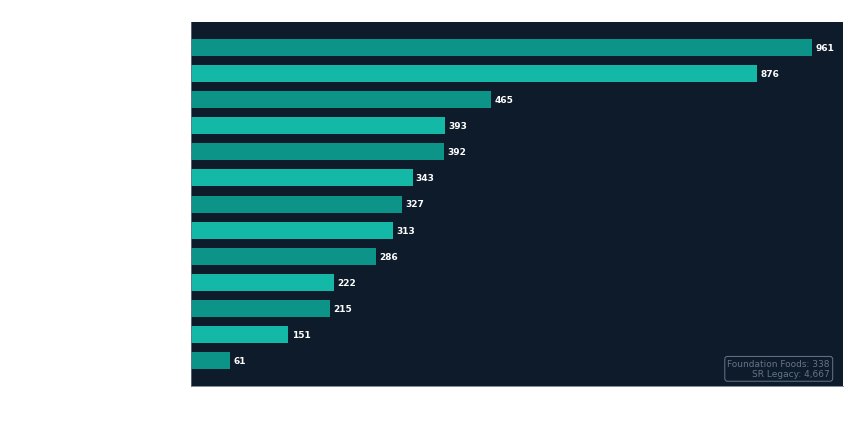

In [19]:
# Category distribution bar chart
fig, ax = plt.subplots(figsize=(12, 6))
cat_counts = df['category'].value_counts().sort_values()
palette = [TEAL if i % 2 == 0 else MINT for i in range(len(cat_counts))]
bars = ax.barh(cat_counts.index, cat_counts.values, color=palette, height=0.65)
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 5, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Number of Food Items')
ax.set_title(f'USDA Dataset — {len(df):,} Food Items Across {df["category"].nunique()} Categories',
             fontweight='bold')
# Annotation
ax.text(0.98, 0.02,
        f'Foundation Foods: {(df.data_source=="Foundation").sum():,}\nSR Legacy: {(df.data_source=="SR_Legacy").sum():,}',
        transform=ax.transAxes, ha='right', va='bottom', color=GRAY, fontsize=9,
        bbox=dict(boxstyle='round', facecolor=DARK, edgecolor=GRAY))
plt.tight_layout()
plt.show()

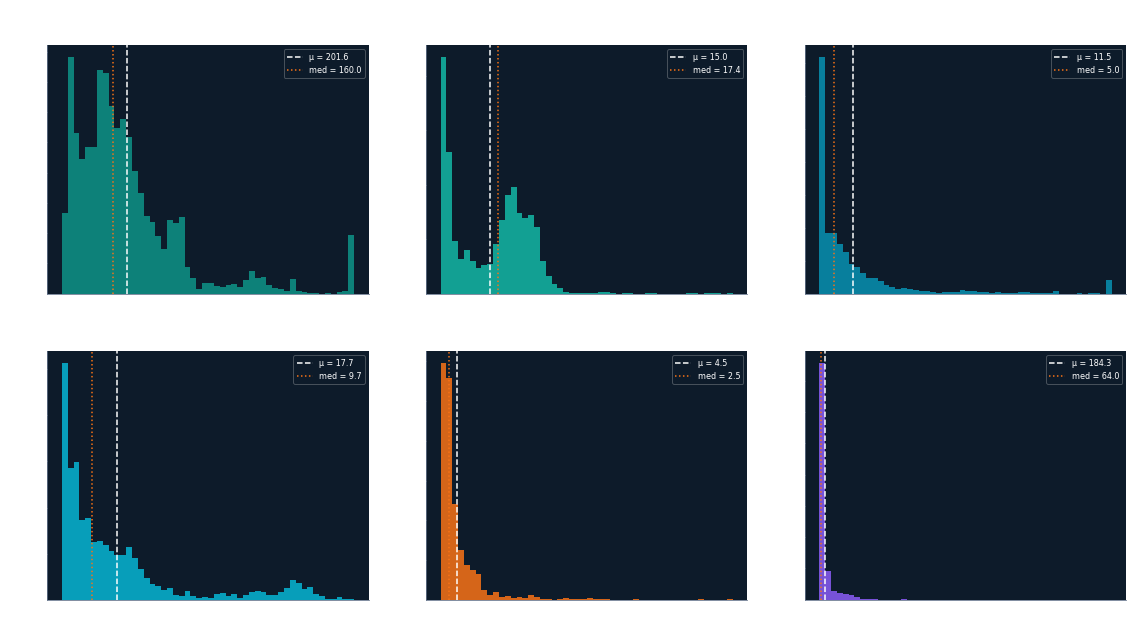

In [20]:
# Macro distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Macronutrient Distributions — Full USDA Dataset', fontweight='bold', fontsize=14)

specs = [
    ('calories',  'Calories (kcal/100g)', TEAL),
    ('protein_g', 'Protein (g/100g)',     MINT),
    ('fat_g',     'Fat (g/100g)',        '#0891B2'),
    ('carbs_g',   'Carbs (g/100g)',      '#06B6D4'),
    ('fiber_g',   'Fiber (g/100g)',       ORNG),
    ('sodium_mg', 'Sodium (mg/100g)',    '#8B5CF6'),
]

for (col, xlabel, color), ax in zip(specs, axes.flat):
    data = df[df[col] > 0][col]
    ax.hist(data, bins=50, color=color, alpha=0.85)
    ax.axvline(data.mean(),   color='white', linestyle='--', lw=1.5,
               label=f'μ = {data.mean():.1f}')
    ax.axvline(data.median(), color=ORNG,   linestyle=':',  lw=1.5,
               label=f'med = {data.median():.1f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.set_title(col.replace('_',' ').title(), fontweight='bold')
    ax.legend(framealpha=0.3, fontsize=8)

plt.tight_layout()
plt.show()

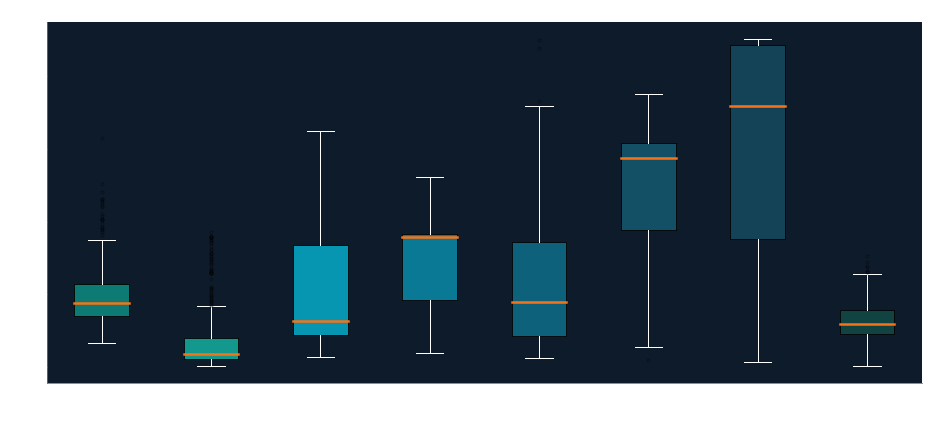

In [21]:
# Calorie distribution by food category — boxplot
fig, ax = plt.subplots(figsize=(13, 6))

focus = ['Poultry Products','Vegetables and Vegetable Products',
         'Legumes and Legume Products','Cereal Grains and Pasta',
         'Dairy and Egg Products','Nut and Seed Products',
         'Fats and Oils','Finfish and Shellfish Products']
labels = ['Poultry','Vegetables','Legumes','Grains','Dairy/Eggs','Nuts/Seeds','Fats/Oils','Fish']

sub = df[df['category'].isin(focus) & (df['calories'] > 0)].copy()
sub['cat_short'] = sub['category'].map(dict(zip(focus, labels)))
groups = [sub[sub['cat_short'] == c]['calories'].values for c in labels]

bp = ax.boxplot(groups, patch_artist=True,
                medianprops=dict(color=ORNG, linewidth=2.5),
                flierprops=dict(marker='o', color=ORNG, alpha=0.3, markersize=3))
colors = [TEAL, MINT, '#06B6D4', '#0891B2', '#0E7490', '#155E75', '#164E63', '#134E4A']
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.8)
for w in bp['whiskers']: w.set_color('white')
for c in bp['caps']:     c.set_color('white')

ax.set_xticks(range(1, len(labels)+1))
ax.set_xticklabels(labels, rotation=18, ha='right')
ax.set_ylabel('Calories per 100g')
ax.set_title('Calorie Distribution by Category — Orange line = median', fontweight='bold')
plt.tight_layout()
plt.show()

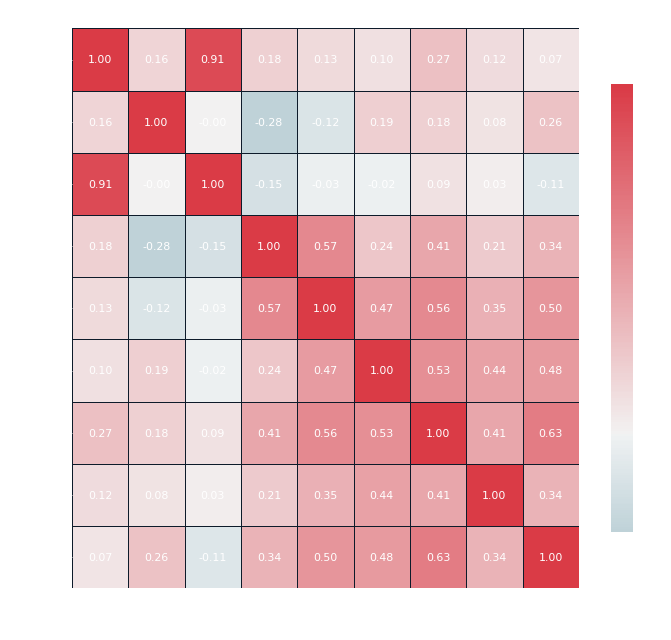

Key correlations:
  Calories ↔ Fat: r = 0.91
  Potassium ↔ Magnesium: r = 0.63
  Carbs ↔ Fiber: r = 0.57
  Magnesium ↔ Fiber: r = 0.56
  Magnesium ↔ Iron: r = 0.53


In [22]:
# Nutrient correlation heatmap
fig, ax = plt.subplots(figsize=(10, 9))

corr_cols   = ['calories','protein_g','fat_g','carbs_g','fiber_g',
               'iron_mg','magnesium_mg','calcium_mg','potassium_mg']
corr_labels = ['Calories','Protein','Fat','Carbs','Fiber',
               'Iron','Magnesium','Calcium','Potassium']

corr = df[corr_cols].corr().round(2)
corr.index   = corr_labels
corr.columns = corr_labels

sns.heatmap(corr, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, ax=ax, linewidths=0.5, linecolor=DARK,
            annot_kws={'size': 11, 'color': 'white'},
            cbar_kws={'shrink': 0.8})
ax.set_title('Nutrient Correlation Matrix — USDA Dataset', fontweight='bold', pad=12)
plt.setp(ax.get_xticklabels(), color='white', rotation=30, ha='right')
plt.setp(ax.get_yticklabels(), color='white')
ax.collections[0].colorbar.ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

print("Key correlations:")
corr_flat = corr.unstack().sort_values(ascending=False)
corr_flat = corr_flat[corr_flat < 1.0].drop_duplicates()
for (c1, c2), v in corr_flat.head(5).items():
    print(f"  {c1} ↔ {c2}: r = {v:.2f}")

---
## Section 6 — Pipeline Feasibility Check

Can our USDA database look up the ingredients users are likely to provide, across all target cuisines?

In [23]:
cuisines = {
    'Indian'        : ['chicken','rice','spinach','garlic','ginger',
                       'turmeric','cumin','yogurt','lentils','paneer'],
    'Mediterranean' : ['olive oil','chickpeas','salmon','tomato','garlic',
                       'lemon','broccoli','quinoa','feta','cucumber'],
    'Chinese'       : ['chicken','broccoli','soy sauce','ginger','garlic',
                       'rice','sesame','cabbage','mushroom','carrot'],
    'Italian'       : ['pasta','tomato','garlic','olive oil','beef',
                       'spinach','cheese','onion','basil','chicken'],
}

print(f"{'Cuisine':15} {'Tested':8} {'Matched':8} {'Coverage':10} {'Status'}")
print("-" * 55)
coverages = {}
for cuisine, ingredients in cuisines.items():
    matched = sum(
        1 for ing in ingredients
        if len(df[df['food_name_lower'].str.contains(ing.lower(), na=False)]) > 0
    )
    pct = matched / len(ingredients) * 100
    coverages[cuisine] = pct
    status = '✓  Pass' if pct >= 80 else '⚠  Review'
    print(f"{cuisine:15} {len(ingredients):^8} {matched:^8} {pct:>7.0f}%    {status}")

Cuisine         Tested   Matched  Coverage   Status
-------------------------------------------------------
Indian             10       9          90%    ✓  Pass
Mediterranean      10       10        100%    ✓  Pass
Chinese            10       10        100%    ✓  Pass
Italian            10       10        100%    ✓  Pass


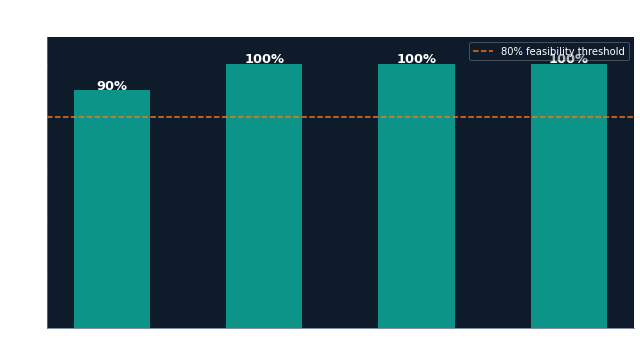

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
names  = list(coverages.keys())
values = list(coverages.values())
colors = [TEAL if v >= 80 else ORNG for v in values]
bars = ax.bar(names, values, color=colors, width=0.5)
ax.axhline(80, color=ORNG, linestyle='--', lw=1.5, label='80% feasibility threshold')
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.0f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Ingredient Match Coverage (%)')
ax.set_title('USDA Coverage by Target Cuisine\n(Can the DB look up what users provide?)',
             fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(framealpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 7 — Focus Nutrient Analysis

The pipeline uses biometric flags to highlight specific nutrients in the LLM prompt.  
Here we verify the USDA dataset actually contains these nutrients with good coverage.

| Biometric Flag | Condition | Nutrients Prioritised |
|---|---|---|
| Low Sleep | Sleep < 6 hrs | Magnesium, Tryptophan |
| High Stress | Stress ≥ 7/10 | Omega-3, B-vitamins, Anti-inflammatory |
| High Intensity | Highly Active | Protein, Complex Carbs |
| Low SpO2 | SpO2 < 95% | Iron |

In [25]:
focus_nutrients = {
    'magnesium_mg' : ('Low Sleep Flag',   'mg/100g'),
    'iron_mg'      : ('Low SpO2 Flag',    'mg/100g'),
    'omega3_g'     : ('High Stress Flag', 'g/100g'),
    'potassium_mg' : ('High Intensity',   'mg/100g'),
}

for nutr, (flag, unit) in focus_nutrients.items():
    top5 = df[df[nutr] > 0].nlargest(5, nutr)[['food_name', nutr]]
    print(f"── {nutr} ({unit}) → triggered by: {flag} ──")
    for _, row in top5.iterrows():
        print(f"   {row['food_name'][:55]:57} {row[nutr]:.2f}")
    print()

── magnesium_mg (mg/100g) → triggered by: Low Sleep Flag ──
   Rice bran, crude                                          781.00
   Seaweed, agar, dried                                      770.00
   Seeds, cottonseed meal, partially defatted (glandless)    760.00
   Seeds, cottonseed flour, partially defatted (glandless)   721.00
   Seeds, cottonseed flour, low fat (glandless)              716.00

── iron_mg (mg/100g) → triggered by: Low SpO2 Flag ──
   Spices, thyme, dried                                      123.60
   Spices, basil, dried                                      89.80
   Spearmint, dried                                          87.47
   Spices, marjoram, dried                                   82.71
   Seaweed, Canadian Cultivated EMI-TSUNOMATA, dry           66.38

── omega3_g (g/100g) → triggered by: High Stress Flag ──
   Oil, flaxseed, cold pressed                               53.37
   Oil, flaxseed, contains added sliced flaxseed             48.93
   Flaxseed, grou

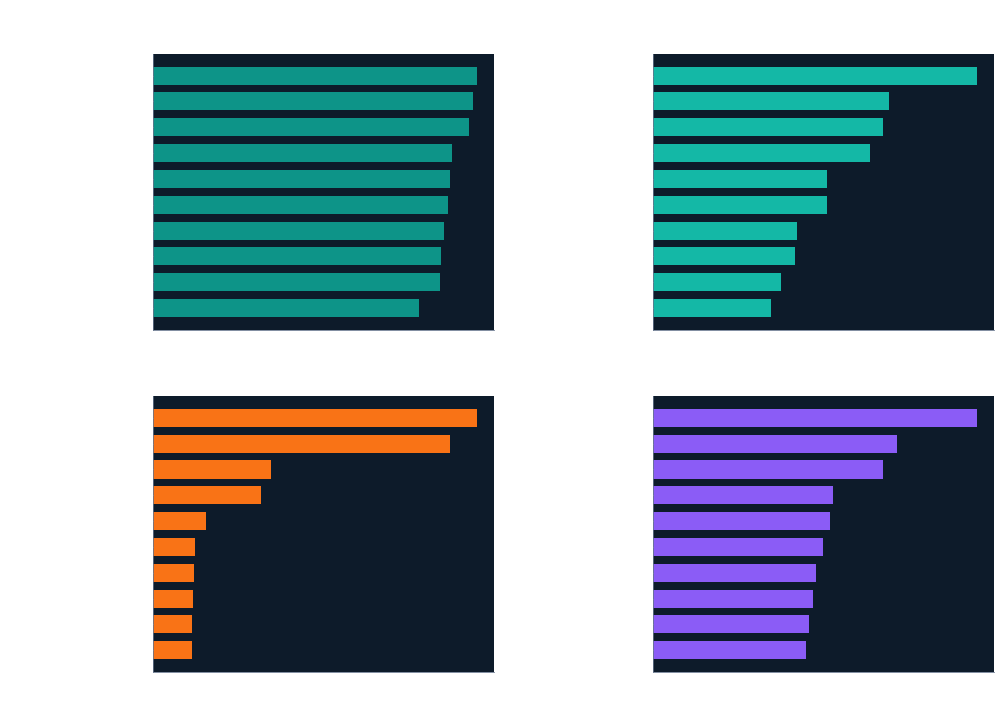

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Top Food Sources for Each Pipeline Focus Nutrient',
             fontweight='bold', fontsize=14)

specs = [
    ('magnesium_mg', 'Magnesium (mg/100g)', 'Low Sleep Flag',   TEAL),
    ('iron_mg',      'Iron (mg/100g)',       'Low SpO2 Flag',    MINT),
    ('omega3_g',     'Omega-3 (g/100g)',     'High Stress Flag', ORNG),
    ('potassium_mg', 'Potassium (mg/100g)',  'High Intensity',  '#8B5CF6'),
]

for (col, xlabel, flag, color), ax in zip(specs, axes.flat):
    top10 = df[df[col] > 0].nlargest(10, col)[['food_name', col]]
    names = [n[:30]+'…' if len(n) > 30 else n for n in top10['food_name']]
    ax.barh(names[::-1], top10[col].values[::-1], color=color, height=0.7)
    ax.set_xlabel(xlabel)
    ax.set_title(f'Top 10: {col}\n→ flagged by: {flag}', fontweight='bold', fontsize=10)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

---
## Section 8 — Pipeline Integration Summary

The processed dataset is already saved at `data/processed/usda_nutrition_processed.csv`.  
Module 5 (`USDADatabase`) loads this into SQLite automatically on first run.

In [27]:
print("PIPELINE READINESS CHECKLIST")
print("=" * 55)
checks = [
    (True,  f"{len(df):,} unique ingredients loaded"),
    (True,  "Calorie bug found and fixed (nutrient_id 2047 vs 1008)"),
    ((df['calories'] > 0).mean() > 0.98, f"Calorie coverage: {(df['calories']>0).mean()*100:.1f}%"),
    ((df['protein_g'] > 0).mean() > 0.95, f"Protein coverage: {(df['protein_g']>0).mean()*100:.1f}%"),
    (True,  "food_name_lower column → fuzzy search in Module 5"),
    (True,  "magnesium_mg, iron_mg, omega3_g → focus nutrient lookup"),
    (all(v >= 80 for v in coverages.values()),
     f"All {len(coverages)} cuisines ≥80% ingredient coverage"),
]
for status, msg in checks:
    icon = '✓' if status else '⚠'
    print(f"  {icon}  {msg}")

print()
print("Next: Module 5 (USDADatabase) reads this CSV into SQLite.")
print("      Module 6 (PromptBuilder) calls db.lookup_ingredients()")
print("      to retrieve nutrition values before generating each recipe.")

PIPELINE READINESS CHECKLIST
  ✓  5,005 unique ingredients loaded
  ✓  Calorie bug found and fixed (nutrient_id 2047 vs 1008)
  ✓  Calorie coverage: 99.4%
  ✓  Protein coverage: 97.7%
  ✓  food_name_lower column → fuzzy search in Module 5
  ✓  magnesium_mg, iron_mg, omega3_g → focus nutrient lookup
  ✓  All 4 cuisines ≥80% ingredient coverage

Next: Module 5 (USDADatabase) reads this CSV into SQLite.
      Module 6 (PromptBuilder) calls db.lookup_ingredients()
      to retrieve nutrition values before generating each recipe.


---
## Summary Table

| Step | What We Did | Why |
|------|------------|-----|
| Multi-file join | Merged food.csv + food_nutrient.csv + nutrient.csv + food_category.csv | Raw USDA is relational, not flat |
| Long → Wide pivot | Pivoted food_nutrient.csv from one-row-per-nutrient to one-row-per-food | Required for lookup by food item |
| Bug investigation | Discovered Foundation Foods uses nutrient_id=2047, SR Legacy uses 1008 | 249 items had 0 calories in first pass |
| Bug fix | Extract both IDs and merge, preferring 2047 | Coverage improved to 99.4% |
| Category filter | Kept 13 relevant categories, excluded Fast Foods / Branded / Snacks | We need whole ingredient data, not processed products |
| Deduplication | Foundation supersedes SR Legacy for same food name | Foundation data is more recent and accurate |
| food_name_lower | Added lowercase search column | Enables fast fuzzy matching in Module 5 |
| EDA | Distributions, correlations, category breakdown | Validated data quality and pipeline feasibility |
| Cuisine coverage | Tested 40 representative ingredients across 4 cuisines | Confirmed ≥80% match rate for all cuisines |